In [17]:
import yfinance as yf

In [19]:
data = yf.Ticker("SPY")

In [21]:
data

yfinance.Ticker object <SPY>

In [23]:
spy = data.history(period = '15y', auto_adjust= False)

In [24]:
spy

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2010-12-27 00:00:00-05:00,125.129997,125.769997,125.040001,125.650002,96.121887,58126000,0.000,0.0,0.0
2010-12-28 00:00:00-05:00,125.900002,125.949997,125.500000,125.830002,96.259567,55309100,0.000,0.0,0.0
2010-12-29 00:00:00-05:00,125.980003,126.199997,125.900002,125.919998,96.328423,58033100,0.000,0.0,0.0
2010-12-30 00:00:00-05:00,125.800003,126.129997,125.529999,125.720001,96.175446,76616900,0.000,0.0,0.0
2010-12-31 00:00:00-05:00,125.529999,125.870003,125.330002,125.750000,96.198395,91218900,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...
2025-12-19 00:00:00-05:00,676.590027,681.090027,676.469971,680.590027,680.590027,103599500,1.993,0.0,0.0
2025-12-22 00:00:00-05:00,683.940002,685.359985,680.590027,684.830017,684.830017,69556700,0.000,0.0,0.0
2025-12-23 00:00:00-05:00,683.919983,688.200012,683.869995,687.960022,687.960022,64840000,0.000,0.0,0.0


In [25]:
spy["sm21"] = spy["Adj Close"].rolling(21).mean()
spy["sm50"] = spy["Adj Close"].rolling(50).mean()

In [26]:
spy["dist_sm21"] = (spy["sm21"] - spy["Adj Close"])/ spy["sm21"]
spy["dist_sm50"] = (spy["sm50"] - spy["Adj Close"])/ spy["sm50"]

In [27]:
prueba = spy.drop(["Open","High","Low","Close","Dividends","Stock Splits", "Capital Gains"] , axis=1)

In [28]:
prueba["Target"] = prueba["Adj Close"].pct_change().shift(-1)

In [35]:
prueba = prueba.dropna()

In [37]:
x = prueba.drop(["Adj Close", "Target"],axis=1)
y = prueba["Target"]

In [39]:
from sklearn.model_selection import train_test_split

In [41]:
x_train, x_test, y_train, y_test  = train_test_split(x,y, shuffle =False, test_size = 0.2, random_state = 42)

In [43]:
x_train

,Volume,sm21,sm50,dist_sm21,dist_sm50
Date,,,,,
2011-03-08 00:00:00-05:00,174615000,101.367940,99.451151,-0.000546,-0.019831
2011-03-09 00:00:00-05:00,153806000,101.383241,99.554273,0.001038,-0.017314
2011-03-10 00:00:00-05:00,301291800,101.287435,99.617156,0.018598,0.002143
2011-03-11 00:00:00-05:00,225621800,101.235341,99.692431,0.011292,-0.004010
2011-03-14 00:00:00-04:00,234974100,101.152647,99.758680,0.016458,0.002715
...,...,...,...,...,...
2022-12-29 00:00:00-05:00,66970900,375.411832,372.298457,0.018178,0.009967
2022-12-30 00:00:00-05:00,84022200,374.341327,372.598649,0.017964,0.013371
2023-01-03 00:00:00-05:00,74850700,373.210792,372.927023,0.019136,0.018390


In [45]:
from sklearn.preprocessing import StandardScaler

In [47]:
estandarizer = StandardScaler()

In [49]:
x_train_scaled = estandarizer.fit_transform(x_train)
x_test_scaled = estandarizer.transform(x_test)

In [51]:
!pip install xgboost

In [52]:
from xgboost import XGBRegressor

In [53]:
xgboost_model = XGBRegressor(
    n_estimators = 1000,
    subsample=0.8,
    learning_rate = 0.05,
    early_stopping_rounds = 10,
    max_depth = 5,
    random_state = 42,
    reg_lambda = 1
)

In [59]:

xgboost_model.fit(
    x_train_scaled, 
    y_train, 
    eval_set=[(x_test_scaled, y_test)],  # <--- ESTA ES LA CLAVE
    verbose=False 
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=10,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
evaluate = xgboost_model.predict(x_test_scaled) 

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [71]:
results = mean_absolute_error(evaluate, y_test)

In [73]:
results

0.006543176093803333

In [75]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

In [87]:
print(f"Dimensiones de entrenamiento: {x_train_scaled.shape}")

Dimensiones de entrenamiento: (2979, 5)


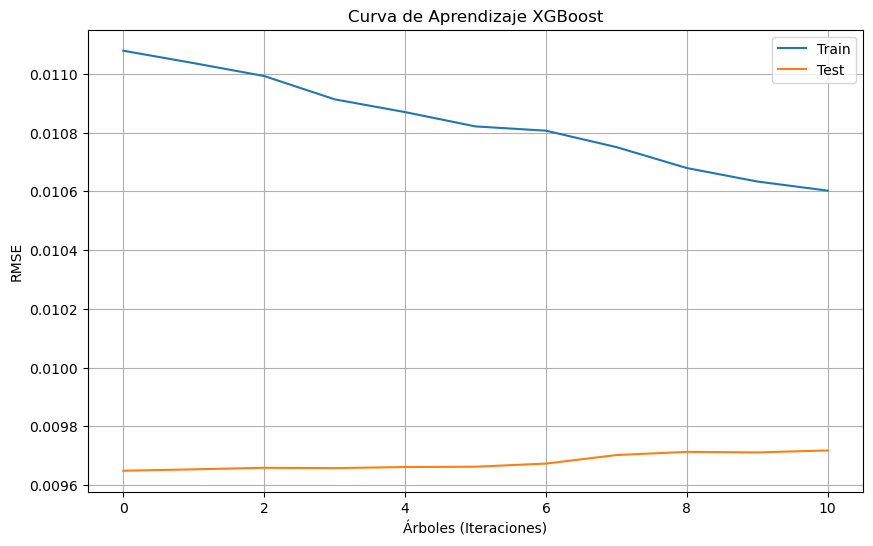

In [89]:
xgboost_model.fit(
    x_train_scaled, y_train,
    eval_set=[(x_train_scaled, y_train), (x_test_scaled, y_test)],
    verbose=False
)

results = xgboost_model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Test')

ax.legend()
plt.ylabel('RMSE')
plt.xlabel('Árboles (Iteraciones)')
plt.title('Curva de Aprendizaje XGBoost')
plt.grid(True)
plt.show()